# Current-speed surrogate model для симулятора бурения

Цель: обучить модель текущей поверхности бурения:

`pressure_axis × pressure_rotation → speed_t`

с учётом текущего состояния: `rotation`, `hardness_score`, `rock_energy_type / cluster`.

Эта модель нужна для симулятора: строить 3D/heatmap surface текущего режима, показывать текущую точку оператора, локальный максимум и replay-сравнение. Это не future-control модель.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
except Exception:
    HAS_LIGHTGBM = False

try:
    import joblib
    HAS_JOBLIB = True
except Exception:
    HAS_JOBLIB = False

RANDOM_STATE = 42
EPS = 1e-6

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1. Загрузка данных

In [2]:
DATA_PATH = "united_with_rock_energy_classes_gmm.csv"

if not Path(DATA_PATH).exists():
    print(f"{DATA_PATH} не найден. Пробую fallback: united_with_rock_energy_classes_hdbscan.csv")
    DATA_PATH = "united_with_rock_energy_classes_hdbscan.csv"

if not Path(DATA_PATH).exists():
    print(f"{DATA_PATH} не найден. Пробую fallback: united.csv")
    DATA_PATH = "united.csv"

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df["processing_time"] = pd.to_datetime(df["processing_time"])
df = df.sort_values(["well_id", "processing_time"]).reset_index(drop=True)

print("Loaded:", DATA_PATH)
print(df.shape)
df.head()

Loaded: united_with_rock_energy_classes_gmm.csv
(415049, 105)


,processing_time,rotation,pressure_axis,pressure_rotation,well_id,speed,dt,energy_proxy,pseudo_mse,drilling_efficiency,rotation_efficiency,pressure_balance,pseudo_mse_roll_median_12,pseudo_mse_roll_mean_12,pseudo_mse_roll_std_12,pseudo_mse_roll_median_30,pseudo_mse_roll_mean_30,pseudo_mse_roll_std_30,pseudo_mse_roll_median_60,pseudo_mse_roll_mean_60,pseudo_mse_roll_std_60,drilling_efficiency_roll_median_12,drilling_efficiency_roll_mean_12,drilling_efficiency_roll_std_12,drilling_efficiency_roll_median_30,drilling_efficiency_roll_mean_30,drilling_efficiency_roll_std_30,drilling_efficiency_roll_median_60,drilling_efficiency_roll_mean_60,drilling_efficiency_roll_std_60,rotation_efficiency_roll_median_12,rotation_efficiency_roll_mean_12,rotation_efficiency_roll_std_12,rotation_efficiency_roll_median_30,rotation_efficiency_roll_mean_30,rotation_efficiency_roll_std_30,rotation_efficiency_roll_median_60,rotation_efficiency_roll_mean_60,rotation_efficiency_roll_std_60,energy_proxy_roll_median_12,energy_proxy_roll_mean_12,energy_proxy_roll_std_12,energy_proxy_roll_median_30,energy_proxy_roll_mean_30,energy_proxy_roll_std_30,energy_proxy_roll_median_60,energy_proxy_roll_mean_60,energy_proxy_roll_std_60,speed_roll_median_12,speed_roll_mean_12,speed_roll_std_12,speed_roll_median_30,speed_roll_mean_30,speed_roll_std_30,speed_roll_median_60,speed_roll_mean_60,speed_roll_std_60,rotation_roll_median_12,rotation_roll_mean_12,rotation_roll_std_12,rotation_roll_median_30,rotation_roll_mean_30,rotation_roll_std_30,rotation_roll_median_60,rotation_roll_mean_60,rotation_roll_std_60,pressure_balance_roll_median_12,pressure_balance_roll_mean_12,pressure_balance_roll_std_12,pressure_balance_roll_median_30,pressure_balance_roll_mean_30,pressure_balance_roll_std_30,pressure_balance_roll_median_60,pressure_balance_roll_mean_60,pressure_balance_roll_std_60,expected_speed_from_controls,formation_residual,relative_formation_residual,formation_residual_roll_median_12,formation_residual_roll_mean_12,formation_residual_roll_std_12,formation_residual_roll_median_30,formation_residual_roll_mean_30,formation_residual_roll_std_30,formation_residual_roll_median_60,formation_residual_roll_mean_60,formation_residual_roll_std_60,relative_formation_residual_roll_median_12,relative_formation_residual_roll_mean_12,relative_formation_residual_roll_std_12,relative_formation_residual_roll_median_30,relative_formation_residual_roll_mean_30,relative_formation_residual_roll_std_30,relative_formation_residual_roll_median_60,relative_formation_residual_roll_mean_60,relative_formation_residual_roll_std_60,hardness_score,label_kmeans,energy_type_kmeans,label_gmm,energy_type_gmm,label_hdbscan,energy_type_hdbscan,rock_energy_label_final,rock_energy_type_final
0,2025-08-24 10:09:50.980,74.256,804,4551,19601,0.002755,NaN,338743.056,1.229314e+08,8.131666e-09,0.016316,0.150140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007751,-0.004997,-0.644553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-08-24 10:10:00.260,73.812,763,3782,19601,0.003030,9.280,279919.984,9.235235e+07,1.082452e-08,0.019517,0.167877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007751,-0.004721,-0.609021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-08-24 10:10:05.199,73.512,879,4407,19601,0.006060,4.939,324846.384,5.359617e+07,1.865497e-08,0.016681,0.166288,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

## 2. Базовая очистка

In [3]:
required = ["processing_time", "well_id", "pressure_axis", "pressure_rotation", "rotation", "speed"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Не хватает колонок: {missing}")

before = len(df)

df = df[
    (df["speed"] > 0) &
    (df["rotation"] > 0) &
    (df["pressure_axis"] > 0) &
    (df["pressure_rotation"] > 0)
].copy()

after = len(df)
print(f"Rows before={before:,}, after={after:,}, removed={before-after:,}")

df[["pressure_axis", "pressure_rotation", "rotation", "speed"]].describe(percentiles=[.01, .05, .5, .95, .99])

Rows before=415,049, after=415,049, removed=0


,pressure_axis,pressure_rotation,rotation,speed
count,415049.000000,415049.000000,415049.000000,415049.000000
mean,17473.667273,14134.146325,103.945315,0.013116
std,4682.982816,3243.523440,13.370361,0.006615
min,317.000000,784.000000,50.010000,0.001002
1%,3713.000000,6271.000000,64.980000,0.002755
5%,6645.000000,8246.000000,81.750000,0.005050
50%,18861.000000,14637.000000,103.158000,0.012120
95%,22343.000000,18758.600000,138.474000,0.024240
99%,23626.000000,20881.000000,139.020000,0.030300
max,24872.000000,26318.000000,139.578000,0.038957


## 3. Проверка hardness_score / cluster

In [4]:
if "energy_proxy" not in df.columns:
    df["energy_proxy"] = df["pressure_axis"] + df["pressure_rotation"] * df["rotation"]

if "pseudo_mse" not in df.columns:
    df["pseudo_mse"] = df["energy_proxy"] / (df["speed"] + EPS)

if "drilling_efficiency" not in df.columns:
    df["drilling_efficiency"] = df["speed"] / (df["energy_proxy"] + EPS)

if "hardness_score" not in df.columns:
    def zscore(s):
        return (s - s.mean()) / (s.std() + EPS)
    df["hardness_score"] = zscore(np.log1p(df["pseudo_mse"])) - zscore(df["drilling_efficiency"])
    print("hardness_score был построен fallback-методом. Лучше использовать датасет из clustering pipeline.")
else:
    print("hardness_score найден в датасете.")

cluster_candidates = [
    "rock_energy_type_final",
    "energy_type_gmm",
    "energy_type_kmeans",
    "energy_type_hdbscan",
    "rock_energy_type",
]

cluster_col = None
for c in cluster_candidates:
    if c in df.columns:
        cluster_col = c
        break

if cluster_col is None:
    df["rock_energy_type_fallback"] = "unknown"
    cluster_col = "rock_energy_type_fallback"

df[cluster_col] = df[cluster_col].fillna("unknown").astype(str)

print("cluster_col:", cluster_col)
df[[cluster_col, "hardness_score", "pseudo_mse", "drilling_efficiency"]].head()

hardness_score найден в датасете.
cluster_col: rock_energy_type_final


,rock_energy_type_final,hardness_score,pseudo_mse,drilling_efficiency
0,unknown,NaN,1.229314e+08,8.131666e-09
1,unknown,NaN,9.235235e+07,1.082452e-08
2,unknown,NaN,5.359617e+07,1.865497e-08
3,unknown,NaN,9.970810e+07,1.002564e-08
4,unknown,NaN,1.907619e+08,5.238679e-09


## 4. Feature engineering для current surface

In [5]:
df["pressure_balance"] = df["pressure_axis"] / (df["pressure_axis"] + df["pressure_rotation"] + EPS)
df["axis_over_rot_pressure"] = df["pressure_axis"] / (df["pressure_rotation"] + EPS)
df["rotation_efficiency"] = df["rotation"] / (df["pressure_rotation"] + EPS)
df["axis_x_rotation"] = df["pressure_axis"] * df["rotation"]
df["rot_pressure_x_rotation"] = df["pressure_rotation"] * df["rotation"]
df["total_pressure"] = df["pressure_axis"] + df["pressure_rotation"]

for col in ["pressure_axis", "pressure_rotation", "rotation", "hardness_score"]:
    for lag in [1, 3, 6]:
        df[f"{col}_lag{lag}"] = df.groupby("well_id")[col].shift(lag)

    for w in [6, 12]:
        shifted = df.groupby("well_id")[col].shift(1)
        df[f"{col}_roll_mean_{w}"] = (
            shifted.groupby(df["well_id"])
                   .rolling(w, min_periods=max(2, w // 2))
                   .mean()
                   .reset_index(level=0, drop=True)
        )
        df[f"{col}_roll_std_{w}"] = (
            shifted.groupby(df["well_id"])
                   .rolling(w, min_periods=max(2, w // 2))
                   .std()
                   .reset_index(level=0, drop=True)
        )

df.head()

,processing_time,rotation,pressure_axis,pressure_rotation,well_id,speed,dt,energy_proxy,pseudo_mse,drilling_efficiency,rotation_efficiency,pressure_balance,pseudo_mse_roll_median_12,pseudo_mse_roll_mean_12,pseudo_mse_roll_std_12,pseudo_mse_roll_median_30,pseudo_mse_roll_mean_30,pseudo_mse_roll_std_30,pseudo_mse_roll_median_60,pseudo_mse_roll_mean_60,pseudo_mse_roll_std_60,drilling_efficiency_roll_median_12,drilling_efficiency_roll_mean_12,drilling_efficiency_roll_std_12,drilling_efficiency_roll_median_30,drilling_efficiency_roll_mean_30,drilling_efficiency_roll_std_30,drilling_efficiency_roll_median_60,drilling_efficiency_roll_mean_60,drilling_efficiency_roll_std_60,rotation_efficiency_roll_median_12,rotation_efficiency_roll_mean_12,rotation_efficiency_roll_std_12,rotation_efficiency_roll_median_30,rotation_efficiency_roll_mean_30,rotation_efficiency_roll_std_30,rotation_efficiency_roll_median_60,rotation_efficiency_roll_mean_60,rotation_efficiency_roll_std_60,energy_proxy_roll_median_12,energy_proxy_roll_mean_12,energy_proxy_roll_std_12,energy_proxy_roll_median_30,energy_proxy_roll_mean_30,energy_proxy_roll_std_30,energy_proxy_roll_median_60,energy_proxy_roll_mean_60,energy_proxy_roll_std_60,speed_roll_median_12,speed_roll_mean_12,speed_roll_std_12,speed_roll_median_30,speed_roll_mean_30,speed_roll_std_30,speed_roll_median_60,speed_roll_mean_60,speed_roll_std_60,rotation_roll_median_12,rotation_roll_mean_12,rotation_roll_std_12,rotation_roll_median_30,rotation_roll_mean_30,rotation_roll_std_30,rotation_roll_median_60,rotation_roll_mean_60,rotation_roll_std_60,pressure_balance_roll_median_12,pressure_balance_roll_mean_12,pressure_balance_roll_std_12,pressure_balance_roll_median_30,pressure_balance_roll_mean_30,pressure_balance_roll_std_30,pressure_balance_roll_median_60,pressure_balance_roll_mean_60,pressure_balance_roll_std_60,expected_speed_from_controls,formation_residual,relative_formation_residual,formation_residual_roll_median_12,formation_residual_roll_mean_12,formation_residual_roll_std_12,formation_residual_roll_median_30,formation_residual_roll_mean_30,formation_residual_roll_std_30,formation_residual_roll_median_60,formation_residual_roll_mean_60,formation_residual_roll_std_60,relative_formation_residual_roll_median_12,relative_formation_residual_roll_mean_12,relative_formation_residual_roll_std_12,relative_formation_residual_roll_median_30,relative_formation_residual_roll_mean_30,relative_formation_residual_roll_std_30,relative_formation_residual_roll_median_60,relative_formation_residual_roll_mean_60,relative_formation_residual_roll_std_60,hardness_score,label_kmeans,energy_type_kmeans,label_gmm,energy_type_gmm,label_hdbscan,energy_type_hdbscan,rock_energy_label_final,rock_energy_type_final,axis_over_rot_pressure,axis_x_rotation,rot_pressure_x_rotation,total_pressure,pressure_axis_lag1,pressure_axis_lag3,pressure_axis_lag6,pressure_axis_roll_mean_6,pressure_axis_roll_std_6,pressure_axis_roll_mean_12,pressure_axis_roll_std_12,pressure_rotation_lag1,pressure_rotation_lag3,pressure_rotation_lag6,pressure_rotation_roll_mean_6,pressure_rotation_roll_std_6,pressure_rotation_roll_mean_12,pressure_rotation_roll_std_12,rotation_lag1,rotation_lag3,rotation_lag6,rotation_roll_mean_6,rotation_roll_std_6,hardness_score_lag1,hardness_score_lag3,hardness_score_lag6,hardness_score_roll_mean_6,hardness_score_roll_std_6,hardness_score_roll_mean_12,hardness_score_roll_std_12
0,2025-08-24 10:09:50.980,74.256,804,4551,19601,0.002755,NaN,338743.056,1.229314e+08,8.131666e-09,0.016316,0.150140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007751,-0.004997,-0.644553,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,0.176664,59701.824,337939.056,5355,NaN,NaN,NaN,NaN,NaN,NaN,

## 5. Features и target

In [6]:
target = "speed"

numeric_features = [
    "pressure_axis",
    "pressure_rotation",
    "rotation",
    "hardness_score",
    "pressure_balance",
    "axis_over_rot_pressure",
    "rotation_efficiency",
    "axis_x_rotation",
    "rot_pressure_x_rotation",
    "total_pressure",
    "pressure_axis_lag1",
    "pressure_axis_lag3",
    "pressure_axis_lag6",
    "pressure_rotation_lag1",
    "pressure_rotation_lag3",
    "pressure_rotation_lag6",
    "rotation_lag1",
    "rotation_lag3",
    "rotation_lag6",
    "hardness_score_lag1",
    "hardness_score_lag3",
    "hardness_score_lag6",
    "pressure_axis_roll_mean_6",
    "pressure_axis_roll_std_6",
    "pressure_rotation_roll_mean_6",
    "pressure_rotation_roll_std_6",
    "rotation_roll_mean_6",
    "rotation_roll_std_6",
    "hardness_score_roll_mean_6",
    "hardness_score_roll_std_6",
]

categorical_features = [cluster_col]

model_cols = numeric_features + categorical_features + [target, "well_id", "processing_time"]
model_df = df.dropna(subset=model_cols).copy()

print(model_df.shape)
model_df[numeric_features + [target]].describe(percentiles=[.01, .05, .5, .95, .99])

(372399, 135)


,pressure_axis,pressure_rotation,rotation,hardness_score,pressure_balance,axis_over_rot_pressure,rotation_efficiency,axis_x_rotation,rot_pressure_x_rotation,total_pressure,pressure_axis_lag1,pressure_axis_lag3,pressure_axis_lag6,pressure_rotation_lag1,pressure_rotation_lag3,pressure_rotation_lag6,rotation_lag1,rotation_lag3,rotation_lag6,hardness_score_lag1,hardness_score_lag3,hardness_score_lag6,pressure_axis_roll_mean_6,pressure_axis_roll_std_6,pressure_rotation_roll_mean_6,pressure_rotation_roll_std_6,rotation_roll_mean_6,rotation_roll_std_6,hardness_score_roll_mean_6,hardness_score_roll_std_6,speed
count,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,3.723990e+05,3.723990e+05,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,372399.000000,3.723990e+05,372399.000000
mean,18388.953131,14618.040038,104.492772,0.028497,0.555255,1.267241,0.007475,1.927114e+06,1.531360e+06,33006.993169,18384.948942,18325.205948,18223.881732,14614.111029,14574.634897,14508.678063,104.470067,104.438018,104.396934,0.024643,0.016817,0.004527,18306.976731,295.167800,14562.805697,1002.907664,104.432305,4.856163,0.014716,7.822183e-02,0.013111
std,3666.928220,2903.378216,12.182553,1.873749,0.043418,0.203481,0.002110,4.599941e+05,3.587707e+05,6140.493043,3651.214122,3705.438585,3802.724090,2897.696763,2916.841831,2949.482045,12.194294,12.238689,12.322846,1.877238,1.884499,1.896688,3624.324291,891.059621,2714.776543,634.737886,9.221370,7.388336,1.884005,7.786307e-02,0.006428
min,528.000000,1101.000000,50.010000,-9.363115,0.021882,0.022372,0.002104,4.658381e+04,7.073044e+04,2564.000000,555.000000,555.000000,555.000000,1101.000000,1101.000000,1101.000000,50.010000,50.010000,50.010000,-9.805650,-10.005506,-10.208969,1282.500000,0.408248,3571.833333,40.877459,52.541000,0.000000,-10.018875,0.000000e+00,0.001002
1%,5701.960000,7463.980000,72.480000,-5.199279,0.394791,0.652323,0.004763,5.372011e+05,6.267300e+05,13802.960000,5867.000000,5733.980000,5517.980000,7536.000000,7479.000000,7372.980000,72.402000,72.180000,71.658000,-5.215425,-5.260527,-5.323850,6370.156667,2.449490,7827.166667,232.742400,73.588000,0.209894,-5.261498,6.760715e-08,0.002755
5%,10770.900000,9308.000000,87.894000,-3.358913,0.486695,0.948159,0.005372,1.051924e+06,9.083344e+05,20660.900000,10760.000000,10487.900000,9970.900000,9309.900000,9241.000000,9130.000000,87.744000,87.384000,86.790000,-3.368020,-3.389710,-3.421509,10696.116667,3.728270,9448.000000,362.795411,89.121900,0.352959,-3.390430,1.069098e-02,0.005050
50%,19400.000000,14957.000000,103.158000,0.261443,0.561031,1.278067,0.006948,2.009580e+06,1.556332e+06,34582.000000,19392.000000,19354.000000,19288.000000,14952.000000,14923.000000,14875.000000,103.158000,103.158000,103.158000,0.259488,0.254185,0.246160,19271.000000,11.726039,14980.833333,864.242424,103.265000,0.933222,0.252911,5.478067e-02,0.012120
95%,22419.000000,18881.000000,138.450000,2.757931,0.608430,1.553824,0.011174,2.678097e+06,2.120298e+06,40318.000000,22415.000000,22402.000000,22382.000000,18875.000000,18854.000000,18823.000000,138.450000,138.450000,138.456000,2.757053,2.755780,2.754468,22378.333333,1768.007916,18394.850000,2078.775425,121.319000,19.131276,2.750467,2.256705e-01,0.024240
99%,23676.000000,20981.020000,139.014000,3.822076,0.629803,1.701266,0.014048,3.057531e+06,2.455409e+06,42494.020000,23672.020000,23660.000000,23643.000000,20977.000000,20950.000000,20909.000000,139.014000,139.014000,139.014000,3.821076,3.820536,3.820033,23628.336667,4956.406210,20108.000000,3632.146489,127.213000,25.750035,3.810816,3.824790e-01,0.030300
max,24872.000000,26318.000000,139.578000,6.613977,0.933514,14.040832,0.121481,3.439116e+06,3.667413e+06,49452.000000,24872.000000,24872.000000,24872.000000,26318.000000,26318.0

## 6. Split по well_id

In [7]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(model_df, groups=model_df["well_id"]))

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

X_train = train_df[numeric_features + categorical_features]
y_train = train_df[target]
X_test = test_df[numeric_features + categorical_features]
y_test = test_df[target]

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Train wells:", train_df["well_id"].nunique())
print("Test wells:", test_df["well_id"].nunique())

Train: (276906, 31)
Test: (95493, 31)
Train wells: 1279
Test wells: 427


## 7. Baseline

In [8]:
baseline_pred = np.full(len(y_test), y_train.median())

print(
    "Baseline median | "
    f"MAE={mean_absolute_error(y_test, baseline_pred):.6f} | "
    f"RMSE={root_mean_squared_error(y_test, baseline_pred):.6f} | "
    f"R2={r2_score(y_test, baseline_pred):.4f}"
)

Baseline median | MAE=0.004977 | RMSE=0.006524 | R2=-0.0231


## 8. Обучение current-speed model

In [9]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ],
    remainder="drop",
)

if HAS_LIGHTGBM:
    regressor = lgb.LGBMRegressor(
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        objective="regression",
        verbosity=-1,
    )
    model_name = "LightGBM"
else:
    regressor = HistGradientBoostingRegressor(
        max_iter=400,
        learning_rate=0.04,
        max_leaf_nodes=63,
        l2_regularization=0.01,
        random_state=RANDOM_STATE,
    )
    model_name = "HistGradientBoosting"

current_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", regressor),
])

current_model.fit(X_train, y_train)

pred = current_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"{model_name} current-speed | MAE={mae:.6f} | RMSE={rmse:.6f} | R2={r2:.4f}")

LightGBM current-speed | MAE=0.002969 | RMSE=0.003972 | R2=0.6208


## 9. Ошибки по energy class

In [10]:
eval_df = test_df[["processing_time", "well_id", cluster_col, "speed"]].copy()
eval_df["pred_speed"] = pred
eval_df["abs_error"] = np.abs(eval_df["speed"] - eval_df["pred_speed"])

error_by_cluster = (
    eval_df
    .groupby(cluster_col)
    .agg(
        rows=("speed", "size"),
        speed_median=("speed", "median"),
        pred_median=("pred_speed", "median"),
        mae=("abs_error", "mean"),
    )
    .sort_values("mae")
)

display(error_by_cluster)

,rows,speed_median,pred_median,mae
rock_energy_type_final,,,,
hard_high_energy,30549,0.00606,0.008878,0.002504
medium_high_energy,19648,0.01212,0.012135,0.002793
medium_low_energy,31958,0.01515,0.015226,0.003150
soft_low_energy,13338,0.01818,0.018845,0.003861


## 10. Permutation importance

In [11]:
sample_n = min(10000, len(X_test))
sample_eval = X_test.sample(sample_n, random_state=RANDOM_STATE)
sample_y = y_test.loc[sample_eval.index]

perm = permutation_importance(
    current_model,
    sample_eval,
    sample_y,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error",
)

importance_df = pd.DataFrame({
    "feature": numeric_features + categorical_features,
    "importance": perm.importances_mean,
    "std": perm.importances_std,
}).sort_values("importance", ascending=False)

display(importance_df.head(30))

,feature,importance,std
3,hardness_score,0.007942,4.390225e-05
19,hardness_score_lag1,0.002821,1.393181e-05
21,hardness_score_lag6,0.000530,1.036103e-05
0,pressure_axis,0.000201,4.556551e-06
4,pressure_balance,0.000170,7.473160e-06
8,rot_pressure_x_rotation,0.000163,2.386390e-06
13,pressure_rotation_lag1,0.000150,6.262845e-06
10,pressure_axis_lag1,0.000149,7.648729e-06
28,hardness_score_roll_mean_6,0.000119,4.606748e-06
1,pressure_rotation,0.000088,3.362080e-06


## 11. Функция построения surface

In [12]:
def make_surface_for_row(
    row,
    model,
    numeric_features,
    categorical_features,
    p_axis_range=None,
    p_rot_range=None,
    grid_size=40,
):
    if p_axis_range is None:
        p_axis_range = (
            model_df["pressure_axis"].quantile(0.05),
            model_df["pressure_axis"].quantile(0.95),
        )
    if p_rot_range is None:
        p_rot_range = (
            model_df["pressure_rotation"].quantile(0.05),
            model_df["pressure_rotation"].quantile(0.95),
        )

    p_axis_grid = np.linspace(p_axis_range[0], p_axis_range[1], grid_size)
    p_rot_grid = np.linspace(p_rot_range[0], p_rot_range[1], grid_size)
    PA, PR = np.meshgrid(p_axis_grid, p_rot_grid)

    candidates = pd.DataFrame({
        "pressure_axis": PA.ravel(),
        "pressure_rotation": PR.ravel(),
    })

    for col in numeric_features:
        if col not in candidates.columns:
            candidates[col] = row[col]

    for col in categorical_features:
        candidates[col] = row[col]

    candidates["pressure_balance"] = candidates["pressure_axis"] / (
        candidates["pressure_axis"] + candidates["pressure_rotation"] + EPS
    )
    candidates["axis_over_rot_pressure"] = candidates["pressure_axis"] / (
        candidates["pressure_rotation"] + EPS
    )
    candidates["rotation_efficiency"] = candidates["rotation"] / (
        candidates["pressure_rotation"] + EPS
    )
    candidates["axis_x_rotation"] = candidates["pressure_axis"] * candidates["rotation"]
    candidates["rot_pressure_x_rotation"] = candidates["pressure_rotation"] * candidates["rotation"]
    candidates["total_pressure"] = candidates["pressure_axis"] + candidates["pressure_rotation"]

    Z = model.predict(candidates[numeric_features + categorical_features]).reshape(PA.shape)

    best_idx = np.argmax(Z)
    best = {
        "pressure_axis": PA.ravel()[best_idx],
        "pressure_rotation": PR.ravel()[best_idx],
        "pred_speed": Z.ravel()[best_idx],
    }

    current_pred = model.predict(pd.DataFrame([row[numeric_features + categorical_features]]))[0]

    current = {
        "pressure_axis": row["pressure_axis"],
        "pressure_rotation": row["pressure_rotation"],
        "speed": row["speed"],
        "pred_speed": current_pred,
        "cluster": row[cluster_col],
        "hardness_score": row["hardness_score"],
        "rotation": row["rotation"],
    }

    return PA, PR, Z, current, best

## 12. 3D surface для одной точки

Current: {'pressure_axis': np.int64(19651), 'pressure_rotation': np.int64(15230), 'speed': np.float64(0.0060599999999999), 'pred_speed': np.float64(0.00805321607825592), 'cluster': 'hard_high_energy', 'hardness_score': np.float64(2.5795997019264187), 'rotation': np.float64(102.372)}
Best on current surface: {'pressure_axis': np.float64(21889.54090909091), 'pressure_rotation': np.float64(18881.0), 'pred_speed': np.float64(0.01107103923671868)}


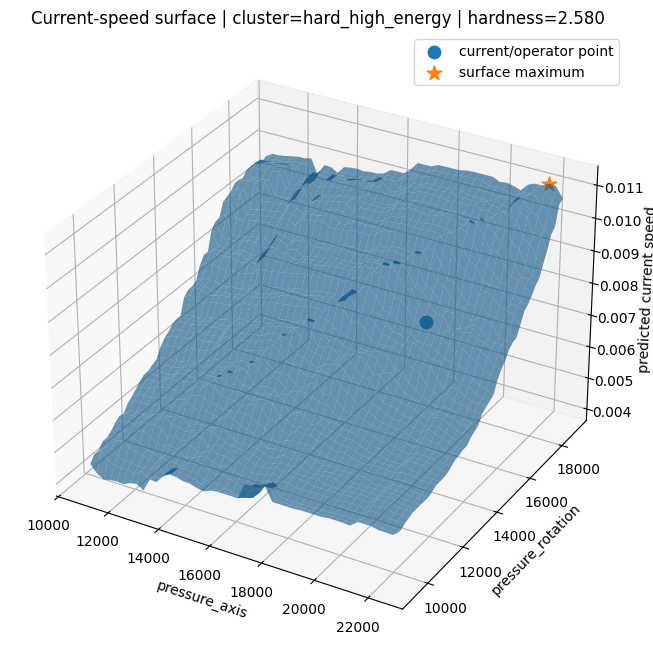

In [13]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

example_row = test_df.sample(1, random_state=RANDOM_STATE).iloc[0]

PA, PR, Z, current, best = make_surface_for_row(
    row=example_row,
    model=current_model,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    grid_size=45,
)

print("Current:", current)
print("Best on current surface:", best)

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(PA, PR, Z, alpha=0.65, linewidth=0, antialiased=True)

ax.scatter(
    current["pressure_axis"],
    current["pressure_rotation"],
    current["pred_speed"],
    s=80,
    marker="o",
    label="current/operator point",
)

ax.scatter(
    best["pressure_axis"],
    best["pressure_rotation"],
    best["pred_speed"],
    s=120,
    marker="*",
    label="surface maximum",
)

ax.set_xlabel("pressure_axis")
ax.set_ylabel("pressure_rotation")
ax.set_zlabel("predicted current speed")
ax.set_title(f"Current-speed surface | cluster={current['cluster']} | hardness={current['hardness_score']:.3f}")
ax.legend()
plt.show()

## 13. Heatmap surface

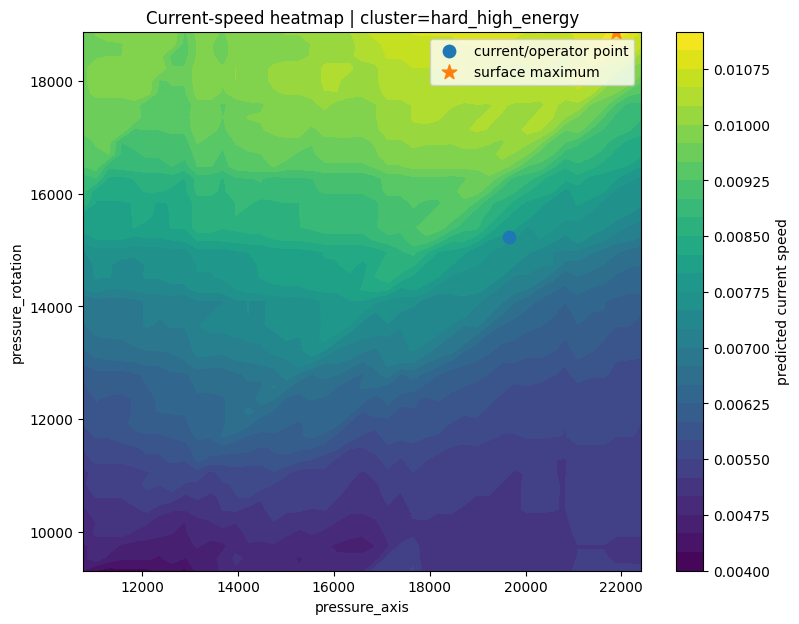

In [14]:
plt.figure(figsize=(9, 7))
plt.contourf(PA, PR, Z, levels=30)
plt.colorbar(label="predicted current speed")

plt.scatter(
    current["pressure_axis"],
    current["pressure_rotation"],
    s=80,
    marker="o",
    label="current/operator point",
)

plt.scatter(
    best["pressure_axis"],
    best["pressure_rotation"],
    s=120,
    marker="*",
    label="surface maximum",
)

plt.xlabel("pressure_axis")
plt.ylabel("pressure_rotation")
plt.title(f"Current-speed heatmap | cluster={current['cluster']}")
plt.legend()
plt.show()

## 14. Replay по одному well_id

well_id: 19677
MAE: 0.004036649024671369


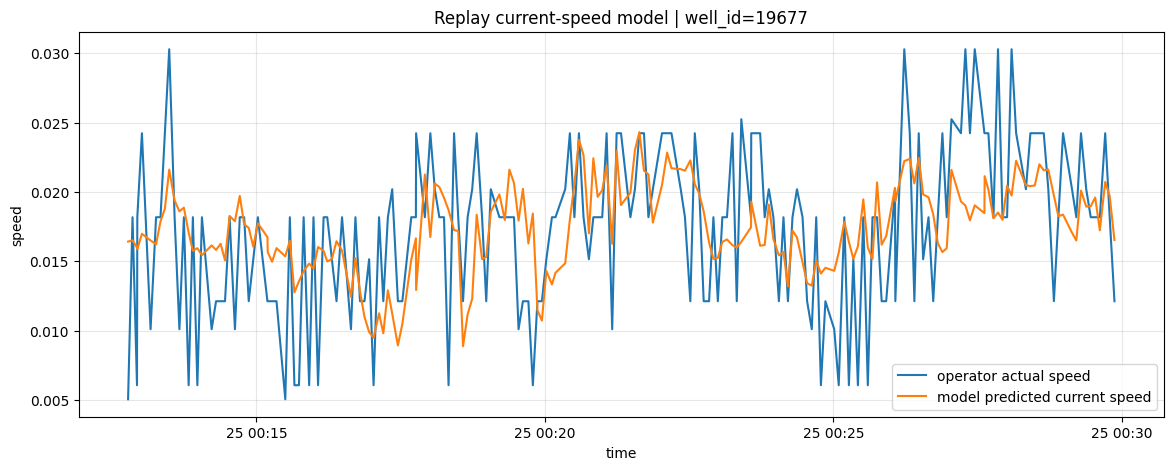

In [ ]:
sample_well = test_df["well_id"].dropna().unique()[0 ]
replay_df = test_df[test_df["well_id"] == sample_well].copy()

replay_df["pred_speed"] = current_model.predict(replay_df[numeric_features + categorical_features])
replay_df["abs_error"] = np.abs(replay_df["speed"] - replay_df["pred_speed"])

print("well_id:", sample_well)
print("MAE:", replay_df["abs_error"].mean())

plt.figure(figsize=(14, 5))
plt.plot(replay_df["processing_time"], replay_df["speed"], label="operator actual speed")
plt.plot(replay_df["processing_time"], replay_df["pred_speed"], label="model predicted current speed")
plt.xlabel("time")
plt.ylabel("speed")
plt.title(f"Replay current-speed model | well_id={sample_well}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 15. Траектория оператора в control-space

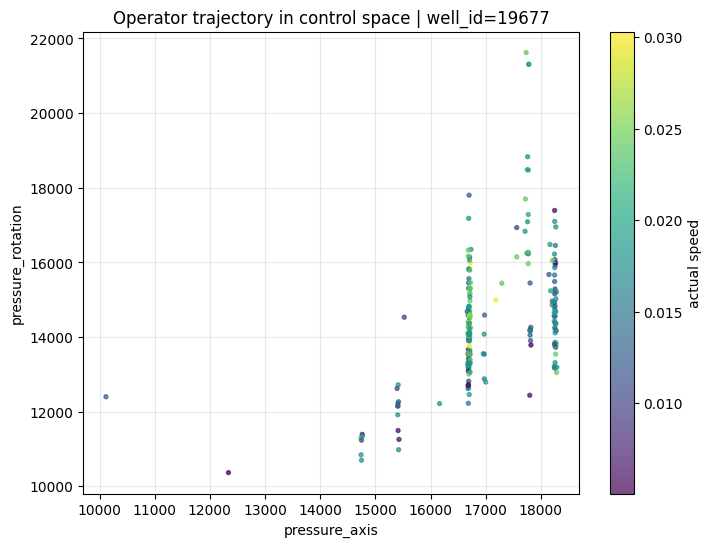

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(
    replay_df["pressure_axis"],
    replay_df["pressure_rotation"],
    c=replay_df["speed"],
    s=8,
    alpha=0.7,
)
plt.colorbar(label="actual speed")
plt.xlabel("pressure_axis")
plt.ylabel("pressure_rotation")
plt.title(f"Operator trajectory in control space | well_id={sample_well}")
plt.grid(True, alpha=0.3)
plt.show()

## 16. Surface gap на replay

In [17]:
def surface_best_for_many_rows(rows, max_rows=100):
    results = []
    subset = rows.iloc[::max(1, len(rows)//max_rows)].copy()

    for idx, row in subset.iterrows():
        PA, PR, Z, current, best = make_surface_for_row(
            row=row,
            model=current_model,
            numeric_features=numeric_features,
            categorical_features=categorical_features,
            grid_size=25,
        )

        results.append({
            "processing_time": row["processing_time"],
            "well_id": row["well_id"],
            "cluster": row[cluster_col],
            "hardness_score": row["hardness_score"],
            "current_pressure_axis": row["pressure_axis"],
            "current_pressure_rotation": row["pressure_rotation"],
            "current_speed": row["speed"],
            "current_pred_speed": current["pred_speed"],
            "surface_best_pressure_axis": best["pressure_axis"],
            "surface_best_pressure_rotation": best["pressure_rotation"],
            "surface_best_pred_speed": best["pred_speed"],
            "surface_gap": best["pred_speed"] - current["pred_speed"],
        })

    return pd.DataFrame(results)

surface_replay = surface_best_for_many_rows(replay_df, max_rows=120)
display(surface_replay.head())
surface_replay[["surface_gap"]].describe(percentiles=[.05, .5, .95])

,processing_time,well_id,cluster,hardness_score,current_pressure_axis,current_pressure_rotation,current_speed,current_pred_speed,surface_best_pressure_axis,surface_best_pressure_rotation,surface_best_pred_speed,surface_gap
0,2025-08-25 00:12:46.561,19677,soft_low_energy,-3.872240,12337,10365,0.00505,0.016422,22419.0000,18881.0,0.029651,0.013229
1,2025-08-25 00:12:51.173,19677,soft_low_energy,-3.757909,14748,10695,0.01818,0.016513,21933.6625,18881.0,0.028923,0.012410
2,2025-08-25 00:12:55.810,19677,soft_low_energy,-3.676561,14762,11388,0.00606,0.015985,21448.3250,18881.0,0.026291,0.010306
3,2025-08-25 00:12:56.143,19677,soft_low_energy,-3.596155,14741,10841,0.01818,0.015875,21448.3250,18881.0,0.026408,0.010533
4,2025-08-25 00:13:00.940,19677,soft_low_energy,-3.676561,14737,11301,0.02424,0.016985,21448.3250,18881.0,0.026908,0.009923


,surface_gap
count,198.000000
mean,0.004433
std,0.002117
min,0.000466
5%,0.001391
50%,0.004146
95%,0.008525
max,0.013229


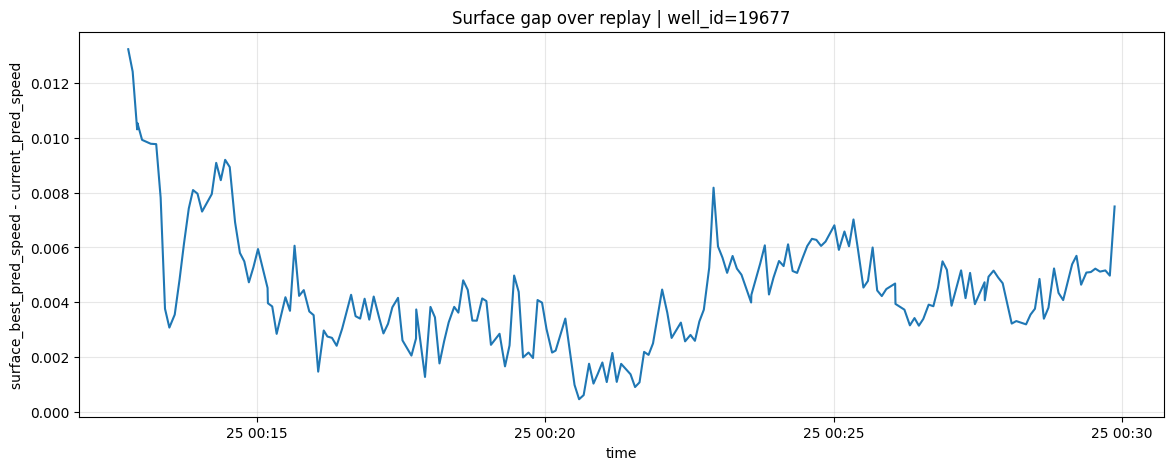

In [18]:
plt.figure(figsize=(14, 5))
plt.plot(surface_replay["processing_time"], surface_replay["surface_gap"])
plt.xlabel("time")
plt.ylabel("surface_best_pred_speed - current_pred_speed")
plt.title(f"Surface gap over replay | well_id={sample_well}")
plt.grid(True, alpha=0.3)
plt.show()

## 17. Сохранение модели и metadata

In [19]:
ARTIFACT_DIR = Path("current_speed_model_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

if HAS_JOBLIB:
    joblib.dump(current_model, ARTIFACT_DIR / "current_speed_model.joblib")
    print("Saved model:", ARTIFACT_DIR / "current_speed_model.joblib")
else:
    print("joblib не установлен, модель не сохранена.")

metadata = {
    "model_name": model_name,
    "data_path": DATA_PATH,
    "target": target,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "cluster_col": cluster_col,
    "metrics": {
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2),
    },
}

with open(ARTIFACT_DIR / "current_speed_model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Saved metadata:", ARTIFACT_DIR / "current_speed_model_metadata.json")

Saved model: current_speed_model_artifacts\current_speed_model.joblib
Saved metadata: current_speed_model_artifacts\current_speed_model_metadata.json


## 18. Использование в симуляторе

На каждом шаге симулятор передаёт текущий state: `pressure_axis`, `pressure_rotation`, `rotation`, `hardness_score`, `rock_energy_type` и lag/rolling признаки. Модель возвращает `predicted current speed`. Для 3D-графика симулятор строит grid по `pressure_axis / pressure_rotation`, фиксирует остальные признаки текущего состояния и вызывает `model.predict()` для каждой точки grid.

Эта модель нужна для current surface, replay и сравнения с оператором. Для настоящей оптимизации следующего действия позже нужна отдельная future-speed model.